#Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load Dataset

In [2]:
df = pd.read_csv("../data/cs-training.csv")

#Display Random 5 rows

In [4]:
df.sample(5)

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
58973,58974,0,1.000000,61,0,0.308694,3300.0,5,0,1,0,0.0
79873,79874,0,0.000000,67,0,3.358302,800.0,8,0,1,0,0.0
69695,69696,0,0.840013,47,3,1808.000000,NaN,5,0,1,0,1.0
136967,136968,0,0.419058,55,1,0.927035,2370.0,6,0,1,0,0.0
68566,68567,0,0.000000,94,2,0.000000,NaN,7,0,0,0,0.0


#Check Dataset Shape

In [5]:
df.shape

(150000, 12)

#Check Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

#Check Missing Values

In [7]:
df.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

#Check distribution

In [8]:
df[['MonthlyIncome', 'NumberOfDependents']].describe()

,MonthlyIncome,NumberOfDependents
count,1.202690e+05,146076.000000
mean,6.670221e+03,0.757222
std,1.438467e+04,1.115086
min,0.000000e+00,0.000000
25%,3.400000e+03,0.000000
50%,5.400000e+03,0.000000
75%,8.249000e+03,1.000000
max,3.008750e+06,20.000000


#Plot distributions

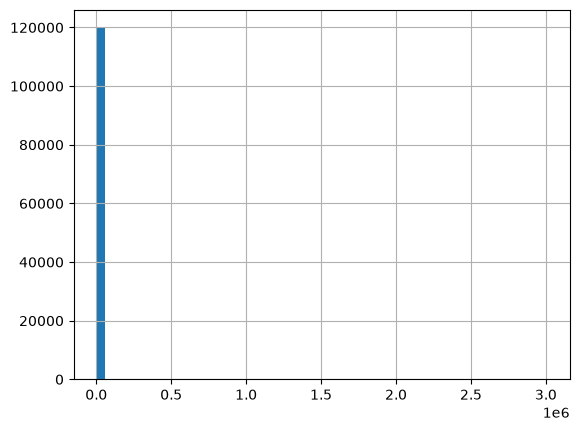

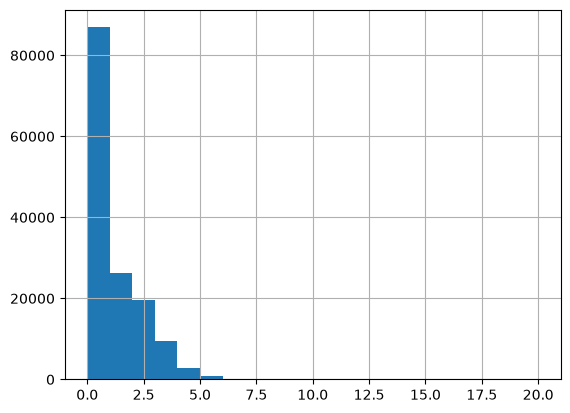

In [9]:
df["MonthlyIncome"].hist(bins=50)
plt.show()

df["NumberOfDependents"].hist(bins=20)
plt.show()

MonthlyIncome contains approximately 20% missing values and exhibits a highly right-skewed distribution with several extreme outliers. Since the mean is influenced by outliers, the missing values were imputed using the median.

NumberOfDependents contains approximately 2.6% missing values and is also right-skewed. As the median is more robust to skewness and outliers, missing values were imputed using the median.

#Handle Missing Values

In [10]:
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())

#Verify

In [11]:
df.isnull().sum()

Unnamed: 0                              0
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

#Check Duplicate Rows

In [12]:
df.duplicated().sum()

np.int64(0)

#Display Column Names

In [13]:
df.columns

Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

#Drop Columns

In [14]:
df = df.drop(columns=['Unnamed: 0'])

#Check Target Variable Distribution

In [15]:
df["SeriousDlqin2yrs"].value_counts()

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

#Import Required Libraries

In [16]:
import scorecardpy as sc

d:\anaconda3\envs\ds311\Lib\site-packages\scorecardpy\germancredit.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


#Calculate Weight of Evidence

In [ ]:
bins = sc.woebin(df, y="SeriousDlqin2yrs")

#Apply WOE Transformation

In [18]:
df_woe = sc.woebin_ply(df, bins)

[INFO] converting into woe values ...
Woe transformating on 150000 rows and 10 columns in 00:00:13


#Display Information Values (IV) of Features

In [20]:
df_iv = sc.iv(df, y = "SeriousDlqin2yrs")
df_iv

,variable,info_value
4,NumberOfTimes90DaysLate,0.881208
2,MonthlyIncome,0.836594
8,NumberOfTime30-59DaysPastDueNotWorse,0.761158
9,NumberOfTime60-89DaysPastDueNotWorse,0.601024
0,DebtRatio,0.406449
1,RevolvingUtilizationOfUnsecuredLines,0.307700
5,age,0.274367
3,NumberOfOpenCreditLinesAndLoans,0.116379
6,NumberRealEstateLoansOrLines,0.068348
7,NumberOfDependents,0.035484


#Drop Weak Features Based on IV

In [21]:
df_woe = df_woe.drop(columns=[
    "NumberRealEstateLoansOrLines_woe",
    "NumberOfDependents_woe",
])

#Display Remaining WOE Features

In [22]:
df_woe.columns

Index(['SeriousDlqin2yrs', 'DebtRatio_woe',
       'RevolvingUtilizationOfUnsecuredLines_woe', 'MonthlyIncome_woe',
       'NumberOfOpenCreditLinesAndLoans_woe', 'NumberOfTimes90DaysLate_woe',
       'age_woe', 'NumberOfTime30-59DaysPastDueNotWorse_woe',
       'NumberOfTime60-89DaysPastDueNotWorse_woe'],
      dtype='object')

#Import library for VIF Calculation

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

#Select Independent Variables

In [24]:
X = df_woe.drop(columns = ["SeriousDlqin2yrs"])

#Calculate VIF For Each Feature

In [25]:
vif = pd.DataFrame()

vif['features'] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values,i)
    for i in range (X.shape[1])
]

vif

,features,VIF
0,DebtRatio_woe,1.098505
1,RevolvingUtilizationOfUnsecuredLines_woe,1.469754
2,MonthlyIncome_woe,1.078169
3,NumberOfOpenCreditLinesAndLoans_woe,1.107664
4,NumberOfTimes90DaysLate_woe,1.364769
5,age_woe,1.120670
6,NumberOfTime30-59DaysPastDueNotWorse_woe,1.325347
7,NumberOfTime60-89DaysPastDueNotWorse_woe,1.297004


#Update Feature Matrix

In [27]:
X = df_woe.drop(columns = "SeriousDlqin2yrs")
y = df_woe["SeriousDlqin2yrs"]

#Split Data Into Training and Testing Sets

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.25,
    random_state=42,
    stratify=y
)

#Import Logistic Regression and GridSearchCV

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

#Create Logistic Regression Model

In [30]:
log_model = LogisticRegression(max_iter=1000)

#Define Hyperparameter Grid

In [32]:
param_grid = [
    {
        "penalty" : ['l1'],
        "C": [0.01, 0.1, 1, 10],
        "solver": ["liblinear"]
    },
    {
        "penalty" : ['l2'],
        "C": [0.01, 0.1, 1, 10],
        "solver": ["liblinear", "lbfgs"]
    }
]

#Perform Hyperparameter Tuning using GridSearchCV

In [33]:
grid_search = GridSearchCV(
    estimator=log_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

#Train Logistic Regression Model

In [34]:
grid_search.fit(X_train, y_train)

d:\anaconda3\envs\ds311\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.01, 0.1, ...], 'penalty': ['l1'], 'solver': ['liblinear']}, {'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['liblinear', 'lbfgs']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callab

#Display Best Hyperparameters

In [35]:
print("Best Parameters :", grid_search.best_params_)
print("Best F1 Score :", grid_search.best_score_)

Best Parameters : {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Best F1 Score : 0.2712818353466275


#Predict Target Values on Test Data

In [36]:
y_pred = grid_search.predict(X_test)

#Import Model Evaluation Metrics

In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

#Evaluate Logistic Regression Model

In [38]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 :", f1)

Accuracy : 0.9356266666666667
Precision : 0.5567901234567901
Recall : 0.1799680766161213
F1 : 0.2720144752714113


#Display Confusion Matrix

In [39]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[34635   359]
 [ 2055   451]]


#Display Classification Report

In [40]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     34994
           1       0.56      0.18      0.27      2506

    accuracy                           0.94     37500
   macro avg       0.75      0.58      0.62     37500
weighted avg       0.92      0.94      0.92     37500



#Import Decision Tree and GridSearchCV

In [41]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

#Create Decision Tree Classifier

In [42]:
dt_model = DecisionTreeClassifier(random_state=42)

#Define Hyperparameters for Decision Tree

In [43]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

#Perform Hyperparameter Tuning using GridSearchCV

In [44]:
grid_search = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

Train Decision Tree Mode

In [45]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"ve

#Display Best Hyperparameters

In [46]:
print("Best Parameters :", grid_search.best_params_)
print("Best F1 Score :", grid_search.best_score_)

Best Parameters : {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best F1 Score : 0.2372801451577975


#Predict Target Values on Test Dataset

In [47]:
y_pred = grid_search.predict(X_test)

#Import Evaluation Metrics

In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

#Evaluate Decision Tree Model

In [49]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 :", f1)

Accuracy : 0.9349066666666667
Precision : 0.5406758448060075
Recall : 0.17238627294493217
F1 : 0.26142208774583964


#Display Confusion Matrix

In [50]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[34627   367]
 [ 2074   432]]


#Display Classification Report

In [51]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     34994
           1       0.54      0.17      0.26      2506

    accuracy                           0.93     37500
   macro avg       0.74      0.58      0.61     37500
weighted avg       0.92      0.93      0.92     37500



#Feature Importance

In [52]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": grid_search.best_estimator_.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                                    Feature  Importance
4               NumberOfTimes90DaysLate_woe    0.501819
1  RevolvingUtilizationOfUnsecuredLines_woe    0.159612
7  NumberOfTime60-89DaysPastDueNotWorse_woe    0.113527
6  NumberOfTime30-59DaysPastDueNotWorse_woe    0.087991
0                             DebtRatio_woe    0.044338
5                                   age_woe    0.039409
2                         MonthlyIncome_woe    0.031229
3       NumberOfOpenCreditLinesAndLoans_woe    0.022075


#Visualize Decision Tree

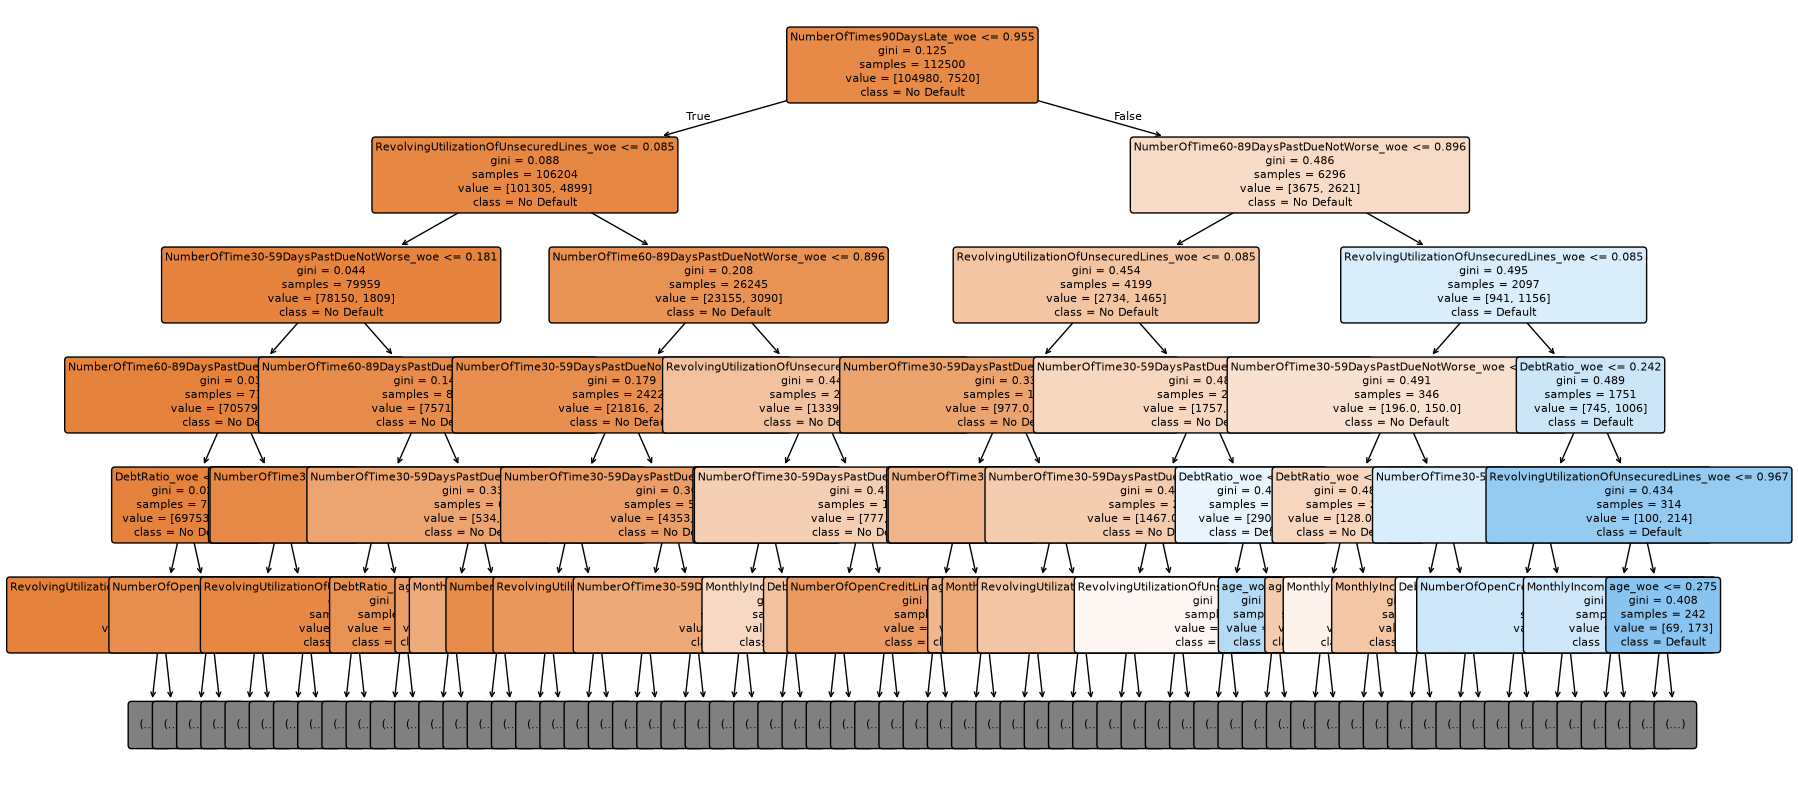

In [54]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    grid_search.best_estimator_,
    feature_names=X.columns,
    class_names=["No Default", "Default"],
    filled=True,
    rounded=True,
    max_depth=5,
    fontsize=8
)

plt.show()

#Import Random Forest and GridSearchCV

In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

#Create Random Forest Model

In [56]:
rf_model = RandomForestClassifier(random_state=42)

#Define Hyperparameter Grid

In [57]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

#Perform Hyperparameter Tuning using GridSearchCV

In [58]:
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

#Train Random Forest Model

In [59]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"

#Display Best Hyperparameters

In [60]:
print("Best Parameters :", grid_search.best_params_)
print("Best F1 Score :", grid_search.best_score_)

Best Parameters : {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best F1 Score : 0.262375468048538


#Predict Target Values on Test Dataset

In [61]:
y_pred = grid_search.predict(X_test)

#Import Evaluation Metrics

In [62]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

#Evaluate Random Forest Model

In [63]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 :", f1)

Accuracy : 0.9328266666666667
Precision : 0.49306296691568835
Recall : 0.18435754189944134
F1 : 0.268370607028754


#Display Confusion Matrix

In [64]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[34519   475]
 [ 2044   462]]


#Display Classification Report

In [65]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.96     34994
           1       0.49      0.18      0.27      2506

    accuracy                           0.93     37500
   macro avg       0.72      0.59      0.62     37500
weighted avg       0.91      0.93      0.92     37500



#Feature Importance

In [66]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": grid_search.best_estimator_.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
4,NumberOfTimes90DaysLate_woe,0.246410
1,RevolvingUtilizationOfUnsecuredLines_woe,0.158527
7,NumberOfTime60-89DaysPastDueNotWorse_woe,0.125184
6,NumberOfTime30-59DaysPastDueNotWorse_woe,0.114207
0,DebtRatio_woe,0.112417
5,age_woe,0.093504
2,MonthlyIncome_woe,0.091188
3,NumberOfOpenCreditLinesAndLoans_woe,0.058562


#Import AdaBoost and GridSearchCV

In [67]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV

#Create AdaBoost Model

In [68]:
ada_model = AdaBoostClassifier(random_state=42)

#Define Hyperparameter Grid

In [69]:
param_grid = {
    "n_estimators": [50, 100],
    "learning_rate": [0.01, 0.1, 0.5, 1.0]
}

#Perform Hyperparameter Tuning using GridSearchCV

In [70]:
grid_search = GridSearchCV(
    estimator=ada_model,
    param_grid=param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

#Train AdaBoost Model

In [71]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClass...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of informatio

#Display Best Hyperparameters

In [72]:
print("Best Parameters :", grid_search.best_params_)
print("Best F1 Score :", grid_search.best_score_)

Best Parameters : {'learning_rate': 0.5, 'n_estimators': 100}
Best F1 Score : 0.28929776060939255


#Predict Target Values on Test Dataset

In [73]:
y_pred = grid_search.predict(X_test)

#Import Evaluation Metrics

In [74]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

#Evaluate AdaBoost Model

In [75]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 :", f1)

Accuracy : 0.9352266666666667
Precision : 0.5414424111948332
Recall : 0.20071827613727056
F1 : 0.2928675400291121


#Display Confusion Matrix

In [76]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[34568   426]
 [ 2003   503]]


#Display Classification Report

In [77]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97     34994
           1       0.54      0.20      0.29      2506

    accuracy                           0.94     37500
   macro avg       0.74      0.59      0.63     37500
weighted avg       0.92      0.94      0.92     37500



#Feature Importance

In [78]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": grid_search.best_estimator_.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
4,NumberOfTimes90DaysLate_woe,0.373187
1,RevolvingUtilizationOfUnsecuredLines_woe,0.184252
6,NumberOfTime30-59DaysPastDueNotWorse_woe,0.117960
7,NumberOfTime60-89DaysPastDueNotWorse_woe,0.112729
5,age_woe,0.084449
0,DebtRatio_woe,0.065398
3,NumberOfOpenCreditLinesAndLoans_woe,0.050444
2,MonthlyIncome_woe,0.011582


#Import XGBoost and GridSearchCV

In [79]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

#Create XGBoost Model

In [80]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

#Define Hyperparameter Grid

In [81]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

#Perform Hyperparameter Tuning

In [82]:
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

#Train XGBoost Model

In [83]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbos

#Display Best Parameters

In [84]:
print("Best Parameters :", grid_search.best_params_)
print("Best F1 Score :", grid_search.best_score_)

Best Parameters : {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best F1 Score : 0.2703613255070166


#Predict on Test Data

In [85]:
y_pred = grid_search.predict(X_test)

#Evaluate XGBoost Model

In [86]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 :", f1)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy : 0.9357066666666667
Precision : 0.5602027883396705
Recall : 0.17637669592976857
F1 : 0.2682852807283763
[[34647   347]
 [ 2064   442]]
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     34994
           1       0.56      0.18      0.27      2506

    accuracy                           0.94     37500
   macro avg       0.75      0.58      0.62     37500
weighted avg       0.92      0.94      0.92     37500



#Feature Importance

In [87]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": grid_search.best_estimator_.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
4,NumberOfTimes90DaysLate_woe,0.376152
1,RevolvingUtilizationOfUnsecuredLines_woe,0.286775
7,NumberOfTime60-89DaysPastDueNotWorse_woe,0.188670
6,NumberOfTime30-59DaysPastDueNotWorse_woe,0.095263
5,age_woe,0.019691
0,DebtRatio_woe,0.017378
3,NumberOfOpenCreditLinesAndLoans_woe,0.008560
2,MonthlyIncome_woe,0.007512


## Final Project Conclusion

Five classification models were trained and evaluated: Logistic Regression, Decision Tree, Random Forest, AdaBoost, and XGBoost. Since the dataset is imbalanced, model selection was based primarily on Precision, Recall, and F1-Score rather than Accuracy. Among all the models, AdaBoost achieved the highest Recall (20.07%) and the highest F1-Score (29.29%), making it the most effective model for identifying customers likely to default. Therefore, AdaBoost was selected as the final model for the Credit Default Risk Prediction project.